# 03 - Model Training

Train a custom CNN on the processed brain tumor MRI dataset using on-the-fly normalization and augmentation, then evaluate it on the held-out test split.

## Workflow

1. Load `data/processed/Training` and `data/processed/Testing` with `image_dataset_from_directory`.
2. Split training into train and validation sets.
3. Apply `Rescaling(1./255)` in the model and training-only augmentation layers.
4. Build and train a custom CNN.
5. Evaluate with accuracy curves, confusion matrix, and classification report.

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. Please go to 'Runtime' > 'Change runtime type' and select 'T4 GPU'.")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)
assert len(gpus) > 0, (
    'No GPU detected. In Colab: Runtime > Change runtime type > T4 GPU. '
    'On local CPU-only machines this assertion will always fail; comment it out if intentionally running on CPU.'
)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from __future__ import annotations
import os
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    # Adjust this to match your actual cloned repo folder name in Colab
    PROJECT_ROOT = Path('/content/') # Corrected to point to /content where data was unzipped
    # Save models/outputs to Drive so they survive runtime disconnects
    MODELS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/models')
    OUTPUTS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/outputs')
else:
    def find_project_root(start: Path | None = None) -> Path:
        start = start or Path.cwd()
        for candidate in [start, *start.parents]:
            if (candidate / 'data' / 'raw' / 'Training').exists() and (candidate / 'data' / 'raw' / 'Testing').exists():
                return candidate
        raise FileNotFoundError('Could not locate data/raw/Training and data/raw/Testing.')

    PROJECT_ROOT = find_project_root()
    MODELS_DIR = PROJECT_ROOT / 'models'
    OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' # Re-added definition
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' # Re-added definition
AUGMENTED_DIR = PROJECT_ROOT / 'data' / 'augmented' # Re-added definition

TRAIN_DIR = RAW_DIR / 'Training' # Changed to use RAW_DIR
TEST_DIR = RAW_DIR / 'Testing' # Changed to use RAW_DIR
CM_DIR = OUTPUTS_DIR / 'confusion_matrix'
GRAPH_DIR = OUTPUTS_DIR / 'graphs'
REPORT_DIR = OUTPUTS_DIR / 'reports'
for folder in [MODELS_DIR, CM_DIR, GRAPH_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.15

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Re-added definition
TARGET_SIZE = (224, 224) # Re-added definition
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'} # Re-added definition

assert TRAIN_DIR.exists() and TEST_DIR.exists(), (
    f"Data not found at {TRAIN_DIR} / {TEST_DIR}. "
    "If in Colab, check your Drive mount and unzip path; if local, check PROJECT_ROOT detection."
)

IN_COLAB, PROJECT_ROOT, TRAIN_DIR, TEST_DIR, RAW_DIR, PROCESSED_DIR, AUGMENTED_DIR, TARGET_SIZE

(True,
 PosixPath('/content'),
 PosixPath('/content/data/raw/Training'),
 PosixPath('/content/data/raw/Testing'),
 PosixPath('/content/data/raw'),
 PosixPath('/content/data/processed'),
 PosixPath('/content/data/augmented'),
 (224, 224))

In [ ]:
train_all_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,  # must match train call's shuffle+seed for a correct complementary split
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,  # keep False here: no split happening, and we need y_true order to match predictions later
)

class_names = train_all_ds.class_names
num_classes = len(class_names)

train_ds = train_all_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

class_names, num_classes

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.


(['glioma', 'meningioma', 'notumor', 'pituitary'], 4)

/tmp/ipykernel_15336/3561529803.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette='viridis')
/tmp/ipykernel_15336/3561529803.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette='magma')


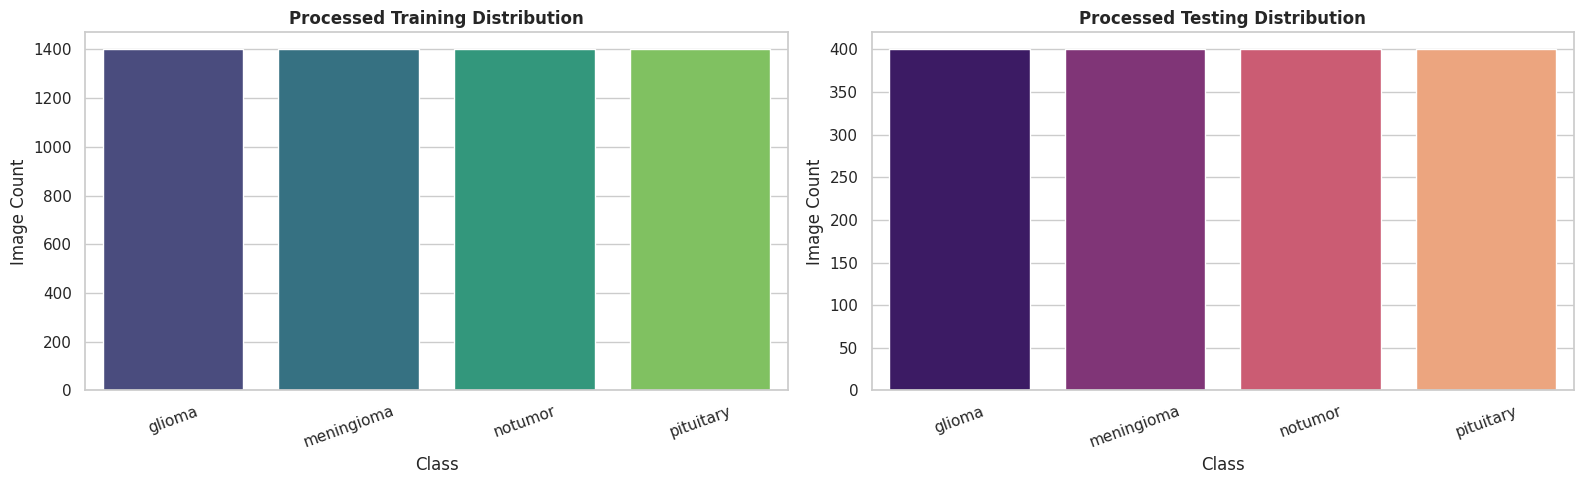

In [ ]:
def count_images(split_dir):
    counts = {}
    for class_name in class_names:
        class_dir = Path(split_dir) / class_name
        counts[class_name] = sum(1 for p in class_dir.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}) if class_dir.exists() else 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette='viridis')
axes[0].set_title('Processed Training Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette='magma')
axes[1].set_title('Processed Testing Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Image Count')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

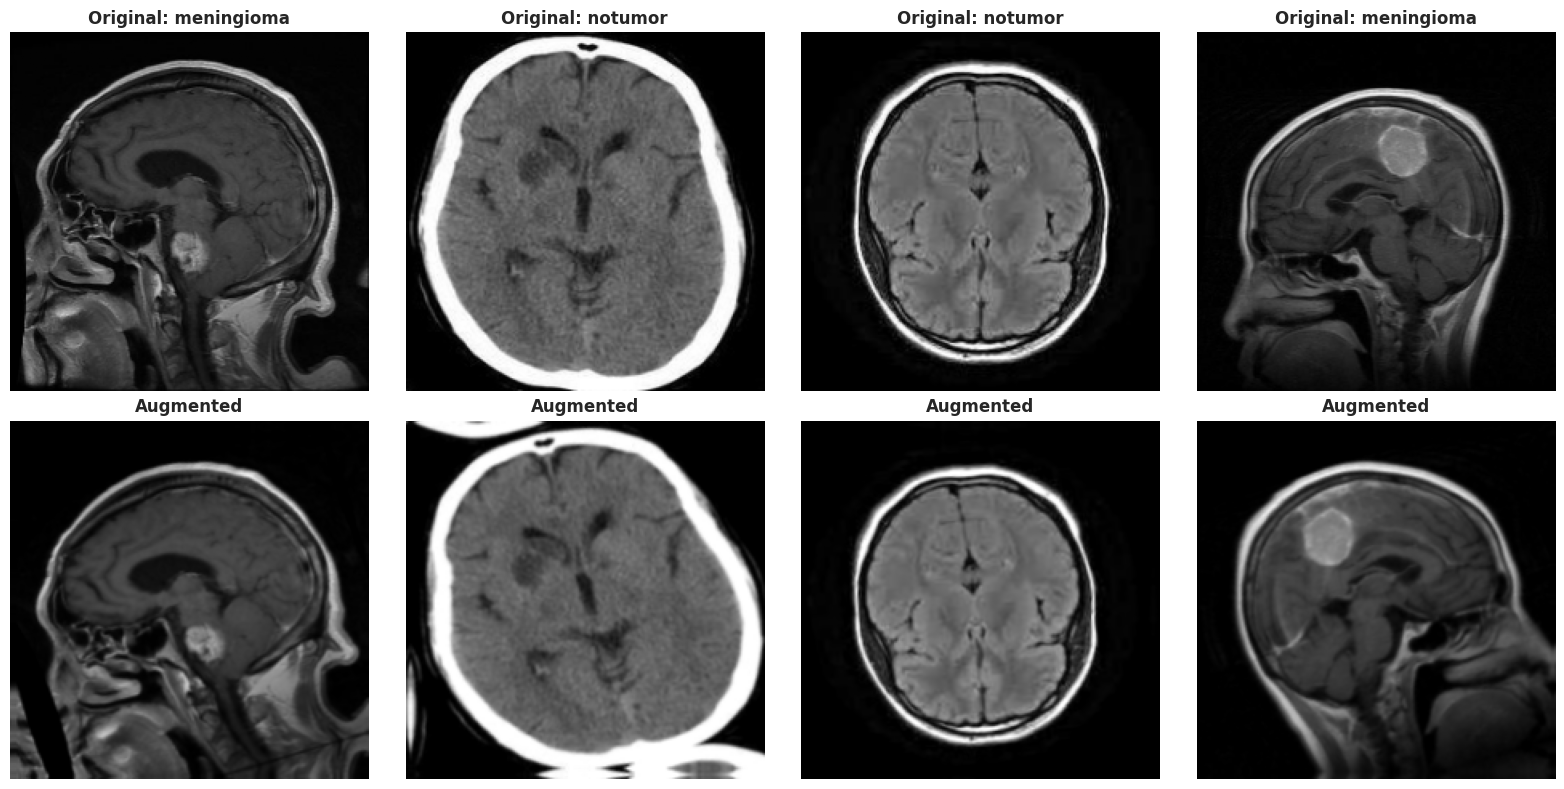

In [ ]:

data_augmentation = keras.Sequential([
    layers.RandomFlip(
        mode="horizontal"
    ),

    layers.RandomRotation(
        factor=0.05
    ),

    layers.RandomZoom(
        height_factor=0.08,
        width_factor=0.08
    ),

    layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    ),

    layers.RandomContrast(
        factor=0.08
    )

], name="brain_mri_augmentation")

def show_augmented_preview(dataset):
    images, labels = next(iter(dataset))
    images_scaled = images / 255.0
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for index in range(4):
        axes[0, index].imshow(images_scaled[index].numpy())
        axes[0, index].set_title(f'Original: {class_names[int(labels[index])]}')
        axes[0, index].axis('off')
        augmented = data_augmentation(images_scaled[index:index + 1], training=True)[0]
        axes[1, index].imshow(tf.clip_by_value(augmented, 0, 1).numpy())
        axes[1, index].set_title('Augmented')
        axes[1, index].axis('off')
    plt.tight_layout()
    plt.show()

show_augmented_preview(train_all_ds)

In [ ]:
from tensorflow.keras import regularizers

L2_REG = 1e-4

def conv_block(x, filters, dropout_rate):
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(1.0 / 255)(inputs)
x = data_augmentation(x)
x = conv_block(x, 32, 0.30)
x = conv_block(x, 64, 0.35)
x = conv_block(x, 128, 0.40)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    128, activation='relu',
    kernel_regularizer=regularizers.l2(L2_REG)
)(x)
x = layers.Dropout(0.50)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='custom_cnn')
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ brain_mri_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 305,380 (1.16 MB)

 Trainable params: 304,484 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
model.compile(
    optimizer=keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
)

model.save(MODELS_DIR / 'custom_cnn.keras')

Epoch 1/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8604 - loss: 0.4138
Epoch 1: val_loss improved from None to 2.96630, saving model to /content/drive/MyDrive/brain_tumor_capstone/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_capstone/models/best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.8628 - loss: 0.4155 - val_accuracy: 0.4250 - val_loss: 2.9663 - learning_rate: 3.0000e-04
Epoch 2/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.8670 - loss: 0.4064
Epoch 2: val_loss improved from 2.96630 to 1.63048, saving model to /content/drive/MyDrive/brain_tumor_capstone/models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_capstone/models/best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 310ms/step - accuracy: 0.8668 - loss: 0.4079 - val_accuracy: 0.6000 - val_loss: 1.6305 - learning_rate: 3.0000e-04
Epoch 3/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step

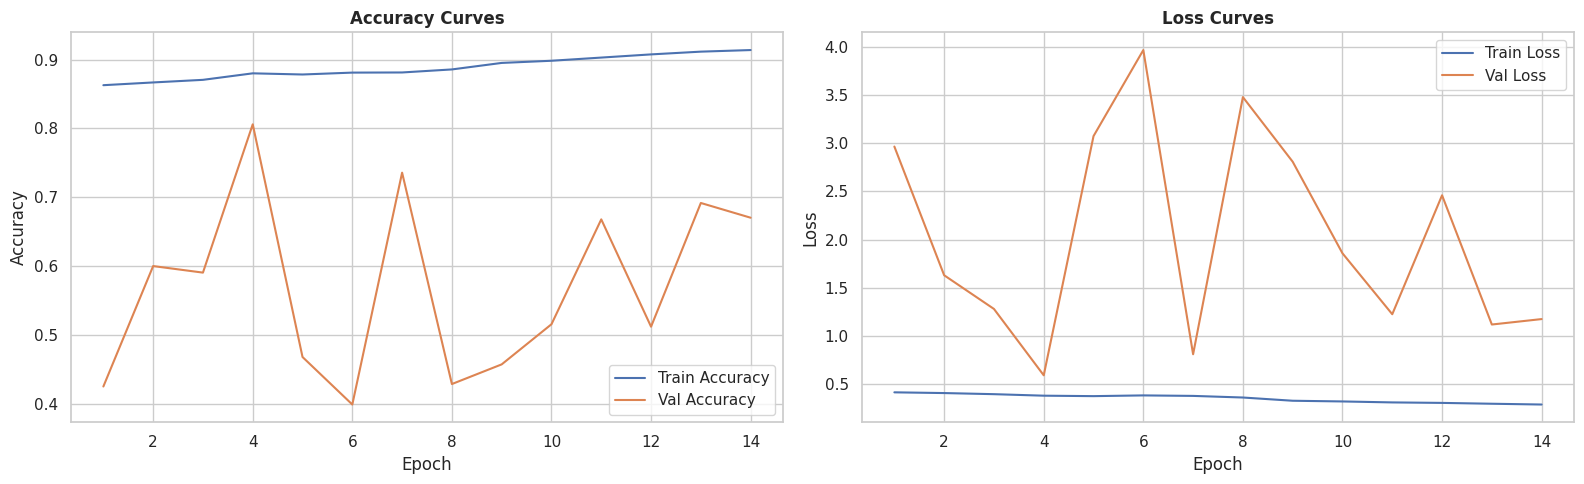

In [17]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(epochs, history_dict['accuracy'], label='Train Accuracy')
axes[0].plot(epochs, history_dict['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(epochs, history_dict['loss'], label='Train Loss')
axes[1].plot(epochs, history_dict['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig(GRAPH_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step
              precision    recall  f1-score   support

      glioma     0.6660    0.7825    0.7195       400
  meningioma     0.7774    0.5500    0.6442       400
     notumor     0.8538    0.8175    0.8352       400
   pituitary     0.8276    0.9600    0.8889       400

    accuracy                         0.7775      1600
   macro avg     0.7812    0.7775    0.7720      1600
weighted avg     0.7812    0.7775    0.7720      1600



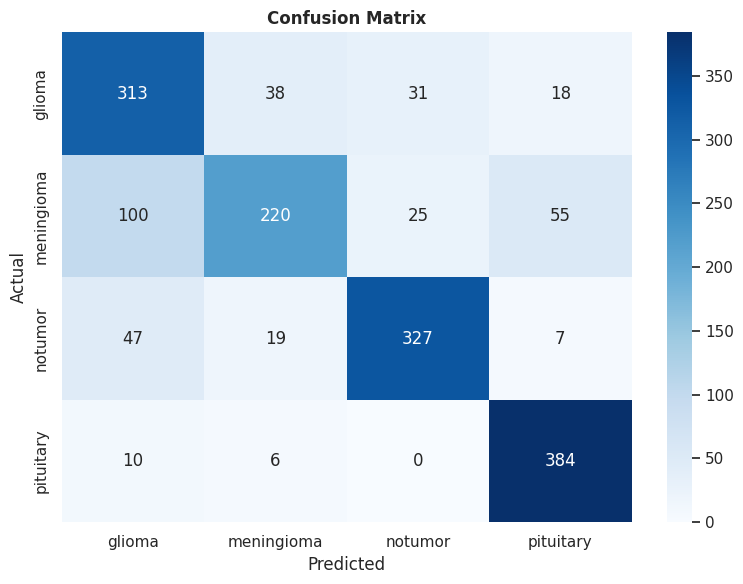

Test loss: 0.7230
Test accuracy: 0.7775


In [18]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(CM_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

with open(REPORT_DIR / 'classification_report.txt', 'w') as report_file:
    report_file.write(report)